# Nuestro primer ejemplo de clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn import metrics

In [2]:
# La raw URL del CSV en GitHub
url = 'https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion15/datos_pinguinos.csv'

# Se lee el CSV y se guarda en un pandas DataFrame
df = pd.read_csv(url)

In [3]:
df.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,ID
0,Torgersen,39.1,18.7,181.0,3750.0,male,1
1,Torgersen,39.5,17.4,186.0,3800.0,female,2
2,Torgersen,40.3,18.0,195.0,3250.0,female,3
3,Torgersen,NaN,NaN,NaN,NaN,NaN,4
4,Torgersen,36.7,19.3,193.0,3450.0,female,5


In [4]:
df = df.dropna()

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

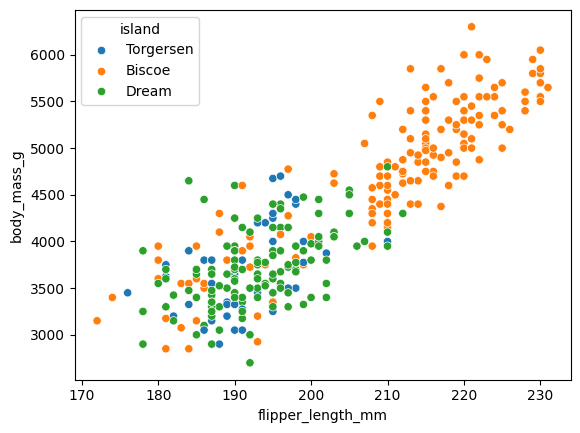

In [5]:
sns.scatterplot(data = df, x = 'flipper_length_mm', y = 'body_mass_g', hue = 'island')

<Axes: xlabel='flipper_length_mm', ylabel='bill_length_mm'>

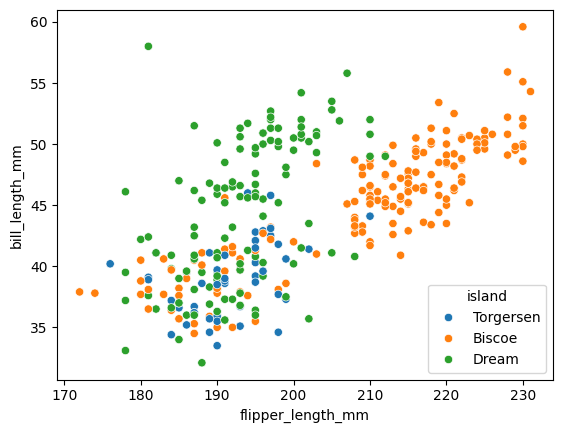

In [6]:
sns.scatterplot(data = df, x = 'flipper_length_mm', y = 'bill_length_mm', hue = 'island')

In [7]:
variables_usadas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[variables_usadas]

In [8]:
X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


## K-means

+ Empecemos con k-means.

+ Lo primero que tenemos que hacer es escalar las variables

¿Por qué escalamos? K-Means calcula distancias euclidianas. Si no escalas, el peso del pingüino (en gramos, aprox. 3000-6000) dominaría totalmente sobre el largo del pico (en mm, aprox. 30-50).

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=variables_usadas)

In [10]:
X_scaled.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
3,-1.335566,1.085877,-0.569284,-0.941606
4,-0.859415,1.747026,-0.783651,-0.692852


In [11]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(X_scaled)

KMeans(n_clusters=3, random_state=0)

<Axes: xlabel='flipper_length_mm', ylabel='bill_length_mm'>

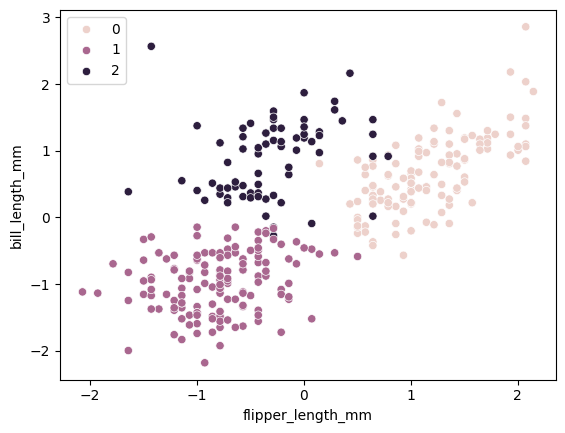

In [12]:
sns.scatterplot(data = X_scaled, x = 'flipper_length_mm', y = 'bill_length_mm', hue = kmeans.labels_)

In [13]:
df['cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
df.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,ID,cluster
0,Torgersen,39.1,18.7,181.0,3750.0,male,1,1
1,Torgersen,39.5,17.4,186.0,3800.0,female,2,1
2,Torgersen,40.3,18.0,195.0,3250.0,female,3,1
4,Torgersen,36.7,19.3,193.0,3450.0,female,5,1
5,Torgersen,39.3,20.6,190.0,3650.0,male,6,1


+ **Métrica de Silueta:** El Silhouette Score mide qué tan parecido es un objeto a su propio clúster en comparación con otros. Un valor cercano a 1 es excelente; cerca de 0 indica clusters traslapados.

+ **Índice Calinski-Harabasz (varianza entre clústers):** Es el cociente entre la dispersión entre los distintos clusters y la dispersión dentro de cada clúster. A mayor puntuación, mejor; indica que los clusters son densos y están bien separados. Es muy rápido de calcular.

+ **Índice Davies-Bouldin:** Mide la "similitud" promedio entre cada cluster y el más parecido a él. A diferencia de las otras, aquí buscamos el valor más bajo. Un valor cercano a 0 es ideal.

In [15]:
sil_score = metrics.silhouette_score(X_scaled, df['cluster'])
ch_score = metrics.calinski_harabasz_score(X_scaled, df['cluster'])
db_score = metrics.davies_bouldin_score(X_scaled, df['cluster'])

print(f"Coeficiente de Silueta: {sil_score}")
print(f"Coeficiente de Calinski-Harabasz: {ch_score}")
print(f"Coeficiente de Davies-Bouldin: {db_score}")

Coeficiente de Silueta: 0.45816494403846464
Coeficiente de Calinski-Harabasz: 425.8237012140982
Coeficiente de Davies-Bouldin: 0.8920082969107653


## Cambiemos el número de clusters

In [16]:
kmeans = KMeans(n_clusters = 4, random_state = 0, n_init='auto')
kmeans.fit(X_scaled)

KMeans(n_clusters=4, random_state=0)

<Axes: xlabel='flipper_length_mm', ylabel='bill_length_mm'>

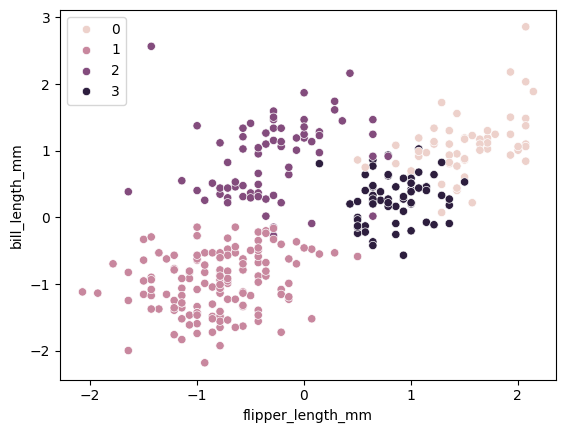

In [17]:
sns.scatterplot(data = X_scaled, x = 'flipper_length_mm', y = 'bill_length_mm', hue = kmeans.labels_)

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

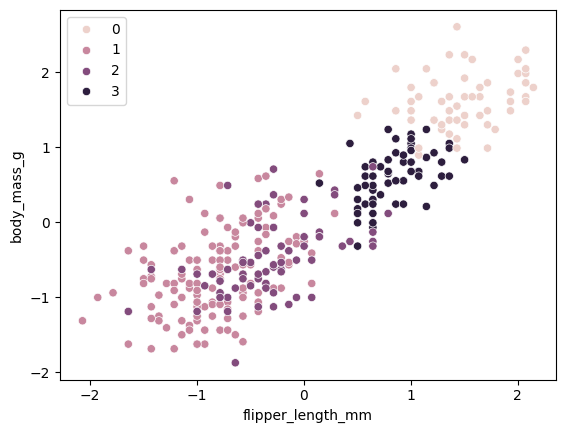

In [18]:
sns.scatterplot(data = X_scaled, x = 'flipper_length_mm', y = 'body_mass_g', hue = kmeans.labels_)

In [19]:
df['cluster'] = kmeans.fit_predict(X_scaled)

In [20]:
df.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,ID,cluster
0,Torgersen,39.1,18.7,181.0,3750.0,male,1,1
1,Torgersen,39.5,17.4,186.0,3800.0,female,2,1
2,Torgersen,40.3,18.0,195.0,3250.0,female,3,1
4,Torgersen,36.7,19.3,193.0,3450.0,female,5,1
5,Torgersen,39.3,20.6,190.0,3650.0,male,6,1


In [21]:
sil_score = metrics.silhouette_score(X_scaled, df['cluster'])
ch_score = metrics.calinski_harabasz_score(X_scaled, df['cluster'])
db_score = metrics.davies_bouldin_score(X_scaled, df['cluster'])

print(f"Coeficiente de Silueta: {sil_score}")
print(f"Coeficiente de Calinski-Harabasz: {ch_score}")
print(f"Coeficiente de Davies-Bouldin: {db_score}")

Coeficiente de Silueta: 0.41008015374808493
Coeficiente de Calinski-Harabasz: 385.29187809183554
Coeficiente de Davies-Bouldin: 0.9166276464632163


¿Y cómo nos "decidimos" qué $K$ usar?

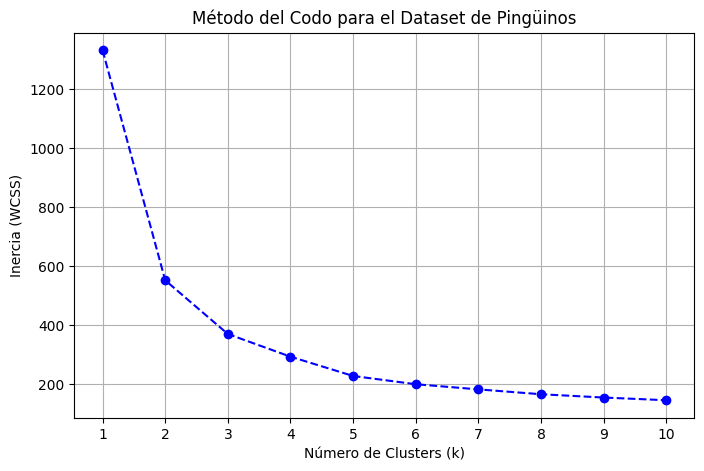

In [22]:
# Calculamos la inercia para diferentes valores de K (por ejemplo, de 1 a 10)
intercia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    intercia.append(model.inertia_)

# Graficamos los resultados
plt.figure(figsize=(8, 5))
plt.plot(K_range, intercia, marker='o', linestyle='--', color='b')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo para el Dataset de Pingüinos')
plt.xticks(K_range)
plt.grid(True)
plt.show()

¿Cómo se interpreta el gráfico?

Imagina que el gráfico es un brazo humano. Buscamos el punto donde la caída drástica de la curva se detiene y comienza a aplanarse; ese "doblez" o codo es nuestro número óptimo de clústers.

+ **Inercia Alta:** Indica que los puntos están muy lejos de los centros de sus clusters (el modelo es demasiado simple).

+ **Inercia Baja:** Indica que los clusters son muy compactos.

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

+ No pide que "adivines" el número de clusters. Busca "islas" de alta densidad de puntos.

+ Puede identificar outliers (puntos ruidosos que no pertenecen a ningún grupo)

In [23]:
# Definición del modelo
dbscan = DBSCAN(eps=0.5, min_samples=5)
# eps: Distancia máxima entre dos muestras para que se consideren vecinas
# min_samples: Número mínimo de muestras en un vecindario para ser un "punto núcleo"

# Construya una nueva columna con el cluster propuesto
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

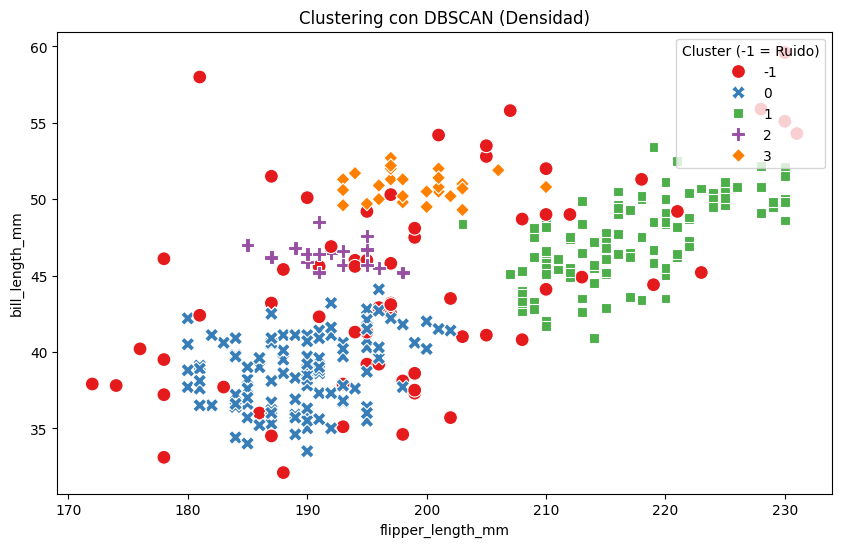

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x = 'flipper_length_mm', y = 'bill_length_mm',
                hue='dbscan_cluster', palette='Set1', style='dbscan_cluster', s=100)

plt.title('Clustering con DBSCAN (Densidad)')
plt.legend(title='Cluster (-1 = Ruido)', loc='upper right')
plt.show()

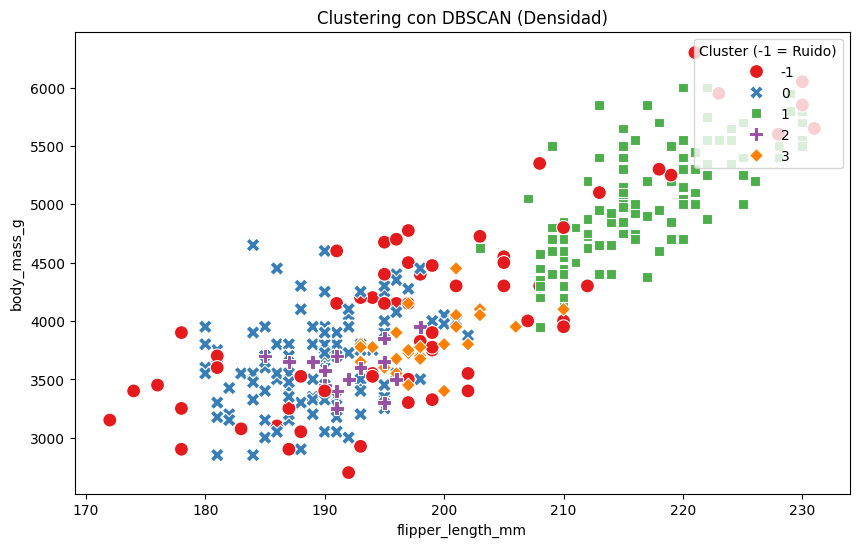

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x = 'flipper_length_mm', y = 'body_mass_g',
                hue='dbscan_cluster', palette='Set1', style='dbscan_cluster', s=100)

plt.title('Clustering con DBSCAN (Densidad)')
plt.legend(title='Cluster (-1 = Ruido)', loc='upper right')
plt.show()

In [26]:
# Conteo de puntos por clúster
print("Conteo de puntos por clúster:")
print(df['dbscan_cluster'].value_counts())

Conteo de puntos por clúster:
dbscan_cluster
 0    115
 1    109
-1     66
 3     27
 2     16
Name: count, dtype: int64


Para entender cómo funciona DBSCAN, imagina que cada punto intenta "conectar" con sus vecinos:

+ **Puntos Núcleo:** Tienen al menos min_samples vecinos dentro de un radio eps.

+ **Puntos Frontera:** Están cerca de un punto núcleo pero no tienen suficientes vecinos propios.

+ **Ruido (Outliers):** Puntos que están "en medio de la nada" y no alcanzan la densidad necesaria.

DBSCAN es muy sensible a sus hiperparámetros

+ Si el `eps` es muy pequeño, todo será ruido

+ Si es muy grande, todos los pingüinos terminarán en un solo clúster gigante.

Calcular las métricas de performance requiere unos pasos adicionales pues el algoritmo marca con -1 a los outliers PERO no significa que todos estén en un mismo clúster

In [27]:
# Extraemos las etiquetas del clustering propuesto
labels = dbscan.labels_

# Contamos cuántos clústers terminó armando el algoritmo
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Contamos cuántos puntos se consideraron outliers
n_ruidosas = list(labels).count(-1)

# Filtrar para construir las métricas
# Se identifica a las etiquetas que no son -1 (i.e. outliers)
mask = labels != -1
if num_clusters > 1:
    sil = metrics.silhouette_score(X_scaled[mask], labels[mask])
    db = metrics.davies_bouldin_score(X_scaled[mask], labels[mask])
else:
    sil, db = 0, 0

print(f"Número estimado de clusters: {num_clusters}")
print(f"Número estimado de puntos de ruido: {n_ruidosas} ({100*n_ruidosas/len(labels):.1f}%)")
print(f"Silhouette Score (sin ruido): {sil:.3f}")
print(f"Davies-Bouldin Index (sin ruido): {db:.3f}")

Número estimado de clusters: 4
Número estimado de puntos de ruido: 66 (19.8%)
Silhouette Score (sin ruido): 0.422
Davies-Bouldin Index (sin ruido): 0.765


+ Sin embargo, dijimos que no debemos confiar "ciegamente" en los algoritmos de clustering.

In [28]:
# La raw URL del CSV en GitHub
url = 'https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion15/dataset_pinguinos.csv'

# Se lee el CSV y se guarda en un pandas DataFrame
df_real = pd.read_csv(url)

In [29]:
df_real.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,ID
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,3
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,4
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,5


+ Este dataset tiene la especie de pingüino a la que pertenece cada observación

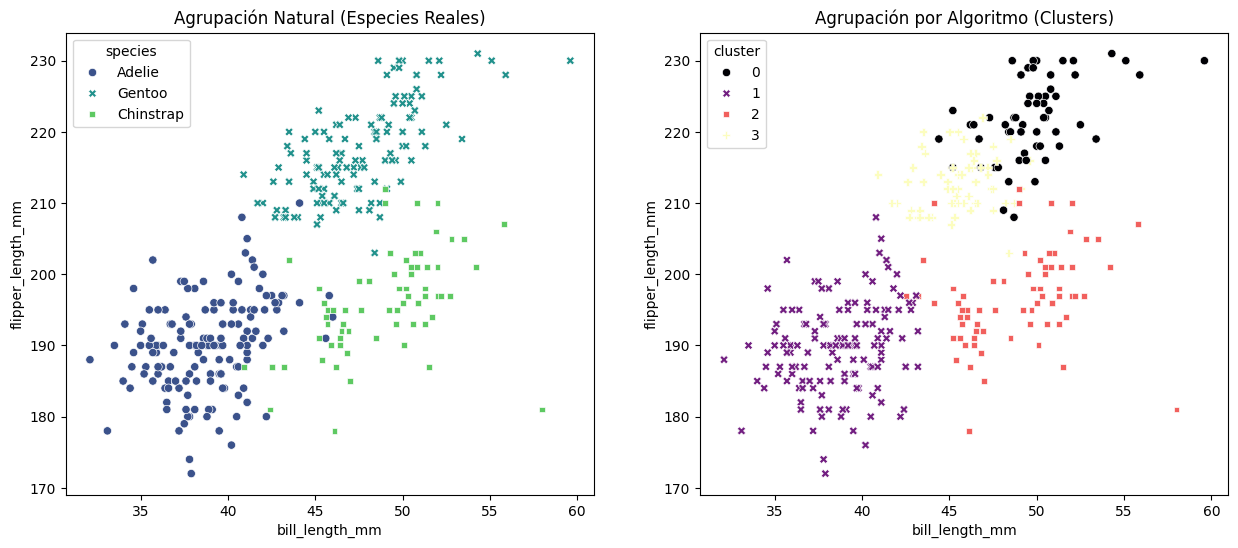

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Especies Reales
sns.scatterplot(data = df_real, x = 'bill_length_mm', y = 'flipper_length_mm',
                hue = 'species', style = 'species', palette = 'viridis', ax=axes[0])
axes[0].set_title('Agrupación Natural (Especies Reales)')

# Subplot 2: Clusters del Algoritmo
sns.scatterplot(data = df, x = 'bill_length_mm', y = 'flipper_length_mm',
                hue = 'cluster', style = 'cluster', palette = 'magma', ax=axes[1])
axes[1].set_title('Agrupación por Algoritmo (Clusters)')

plt.show()

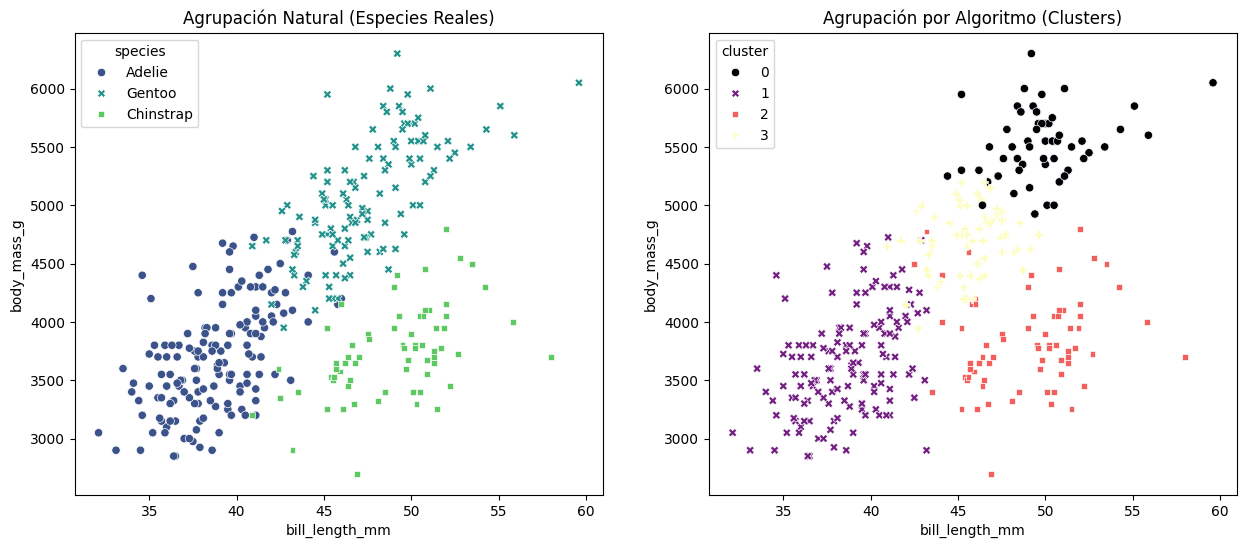

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Especies Reales
sns.scatterplot(data = df_real, x = 'bill_length_mm', y = 'body_mass_g',
                hue = 'species', style = 'species', palette = 'viridis', ax=axes[0])
axes[0].set_title('Agrupación Natural (Especies Reales)')

# Subplot 2: Clusters del Algoritmo
sns.scatterplot(data = df, x = 'bill_length_mm', y = 'body_mass_g',
                hue = 'cluster', style = 'cluster', palette ='magma', ax=axes[1])
axes[1].set_title('Agrupación por Algoritmo (Clusters)')

plt.show()

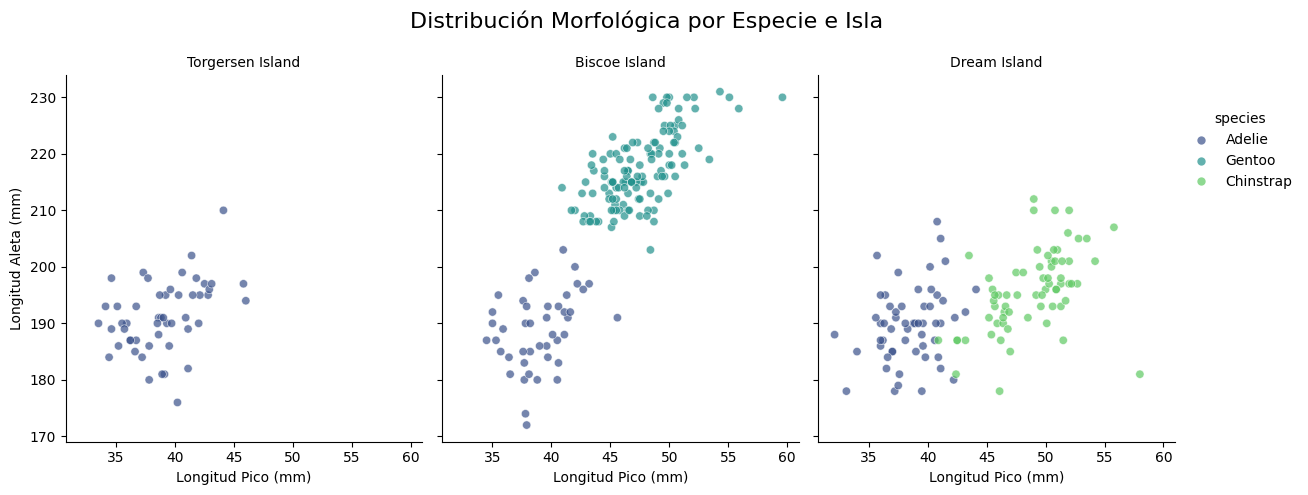

In [32]:
g = sns.relplot(
    data=df_real,
    x = "bill_length_mm",
    y = "flipper_length_mm",
    hue = "species",  # Mapea especie al color
    col = "island",   # Crea una columna de gráficos por cada isla
    palette = "viridis", # Paleta de colores atractiva
    sizes=(10, 200),
    alpha=0.7,      # Transparencia para ver solapamientos
    kind = "scatter",
    height = 5,       # Altura de cada sub-plano
    aspect = 0.8      # Relación de aspecto de cada sub-plano
)

# Algunos ajustes estéticos
g.set_titles("{col_name} Island") # Título de cada subgráfico
g.set_axis_labels("Longitud Pico (mm)", "Longitud Aleta (mm)")
# Ajustar la leyenda para que no tape
sns.move_legend(g, "upper right", bbox_to_anchor=(1, 0.8))

plt.subplots_adjust(top=0.85) # Espacio para el título principal
g.fig.suptitle('Distribución Morfológica por Especie e Isla', fontsize=16)

plt.show()

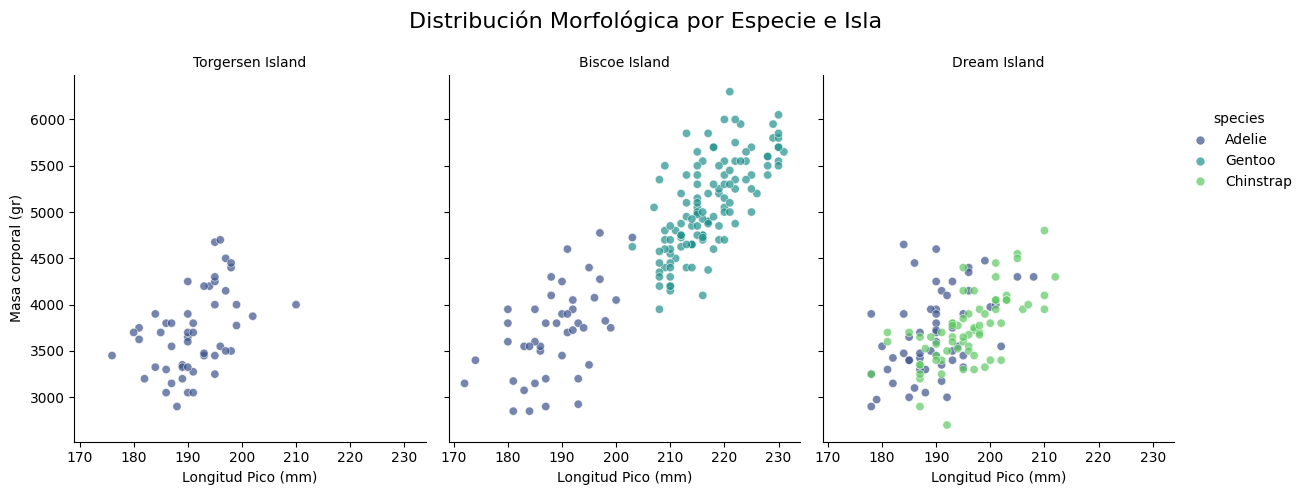

In [33]:
g = sns.relplot(
    data=df_real,
    x = "flipper_length_mm",
    y = "body_mass_g",
    hue = "species",  # Mapea especie al color
    col = "island",   # Crea una columna de gráficos por cada isla
    palette = "viridis", # Paleta de colores atractiva
    sizes=(10, 200),
    alpha=0.7,      # Transparencia para ver solapamientos
    kind = "scatter",
    height = 5,       # Altura de cada sub-plano
    aspect = 0.8      # Relación de aspecto de cada sub-plano
)

# Algunos ajustes estéticos
g.set_titles("{col_name} Island") # Título de cada subgráfico
g.set_axis_labels("Longitud Pico (mm)", "Masa corporal (gr)")
# Ajustar la leyenda para que no tape
sns.move_legend(g, "upper right", bbox_to_anchor=(1, 0.8))

plt.subplots_adjust(top=0.85) # Espacio para el título principal
g.fig.suptitle('Distribución Morfológica por Especie e Isla', fontsize=16)

plt.show()

## Otra alternativa: Usar k-medianas

+ Implementar K-Medians es una alternativa cuando los datos tienen valores atípicos (outliers)

+ K-Means minimiza la suma de los cuadrados de las distancias (usando la media), K-Medians minimiza la suma de las distancias absolutas (usando la mediana), lo que lo hace mucho más robusto.

+ Esta medida se conoce como distancia Manhattan

In [34]:
# Configuración: 3 clusters, usando distancia de Manhattan (como K-Medians)
kmedianas = AgglomerativeClustering(
    n_clusters = 3,
    metric='manhattan',
    linkage='average'
)

# Entrenamiento
df['cluster_kmedianas'] = kmedianas.fit_predict(X_scaled)

In [35]:
df.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,ID,cluster,dbscan_cluster,cluster_kmedianas
0,Torgersen,39.1,18.7,181.0,3750.0,male,1,1,0,0
1,Torgersen,39.5,17.4,186.0,3800.0,female,2,1,0,0
2,Torgersen,40.3,18.0,195.0,3250.0,female,3,1,0,0
4,Torgersen,36.7,19.3,193.0,3450.0,female,5,1,0,0
5,Torgersen,39.3,20.6,190.0,3650.0,male,6,1,0,0


In [36]:
sil_score = metrics.silhouette_score(X_scaled, df['cluster_kmedianas'])
ch_score = metrics.calinski_harabasz_score(X_scaled, df['cluster_kmedianas'])
db_score = metrics.davies_bouldin_score(X_scaled, df['cluster_kmedianas'])

print(f"Coeficiente de Silueta: {sil_score}")
print(f"Coeficiente de Calinski-Harabasz: {ch_score}")
print(f"Coeficiente de Davies-Bouldin: {db_score}")

Coeficiente de Silueta: 0.4742283484587397
Coeficiente de Calinski-Harabasz: 238.66731208282405
Coeficiente de Davies-Bouldin: 0.5873492971658477


<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

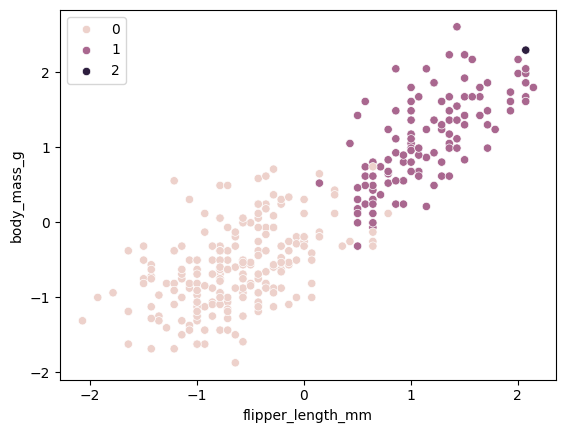

In [37]:
sns.scatterplot(data = X_scaled, x = 'flipper_length_mm', y = 'body_mass_g', hue = kmedianas.labels_)

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

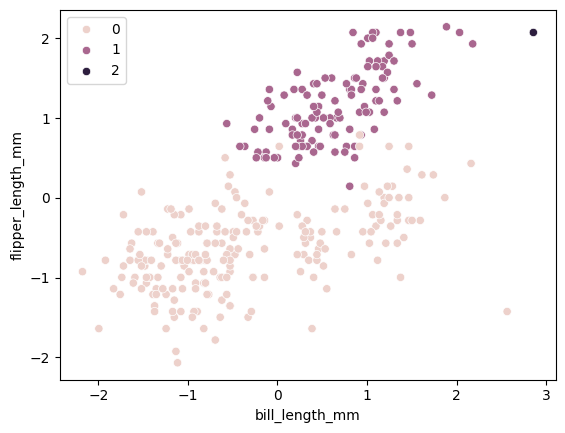

In [38]:
sns.scatterplot(data = X_scaled, x = 'bill_length_mm', y = 'flipper_length_mm', hue = kmedianas.labels_)

### Otra configuración

In [39]:
# Configuración: 4 clusters, usando distancia de Manhattan (como K-Medians)
kmedianas = AgglomerativeClustering(
    n_clusters = 4,
    metric='manhattan',
    linkage='average'
)

# Entrenamiento
df['cluster_kmedianas'] = kmedianas.fit_predict(X_scaled)

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

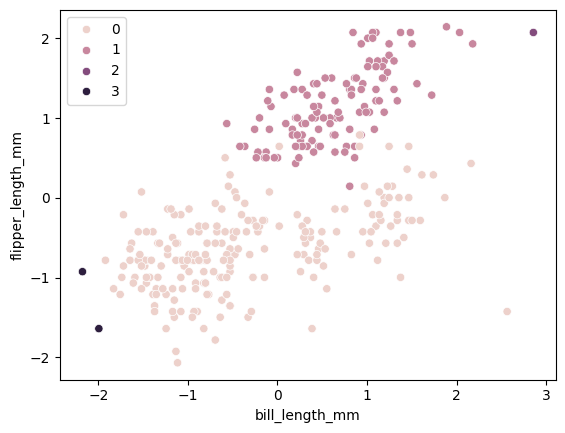

In [40]:
sns.scatterplot(data = X_scaled, x = 'bill_length_mm', y = 'flipper_length_mm', hue = kmedianas.labels_)

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

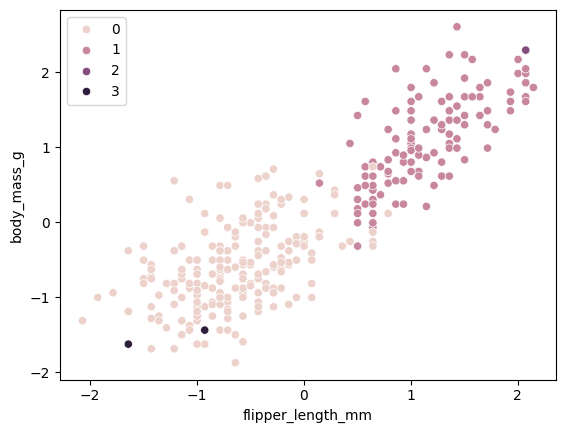

In [41]:
sns.scatterplot(data = X_scaled, x = 'flipper_length_mm', y = 'body_mass_g', hue = kmedianas.labels_)